In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# KNN을 위한 라이브러리 추가
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. 데이터 로드
url = "https://raw.githubusercontent.com/kzming2007/UR3_Cobot_ML/refs/heads/main/dataset/ur3_cobotops.csv"
df = pd.read_csv(url)

## KNN

### [Cell 1] 라이브러리, 데이터 로드 및 파생 변수(is_stationary) 추가

In [3]:
# 2. 결측치 없는 클린 데이터 분리
df_clean = df.dropna().copy()

# ---------------------------------------------------------
# [유지] 2.5 도메인 지식 기반 파생 변수 (Feature Engineering)
# ---------------------------------------------------------
speed_cols = ['Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5']
df_clean['is_stationary'] = (df_clean[speed_cols].abs().sum(axis=1) < 0.05).astype(int)

# 3. 입력 피처(X) 및 타겟(y) 설정
input_cols = [
    'Current_J0', 'Current_J1', 'Current_J2', 'Current_J3', 'Current_J4', 'Current_J5',
    'Speed_J0', 'Speed_J1', 'Speed_J2', 'Speed_J3', 'Speed_J4', 'Speed_J5',
    'is_stationary'
]
X = df_clean[input_cols]
y = df_clean['Tool_current']

print(f"데이터 크기: {df_clean.shape}")
print(f"피처 개수: {len(input_cols)}개, 타겟: Tool_current")

데이터 크기: (7355, 25)
피처 개수: 13개, 타겟: Tool_current


### [Cell 2] 데이터 분할 및 데이터 스케일링 (KNN 필수)

In [4]:
# 1. 80:20으로 Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 데이터 스케일링 [중요]
# 거리 기반 알고리즘인 KNN은 변수의 단위가 매우 중요하므로 StandardScaler를 적용합니다.
scaler = StandardScaler()

# Train 데이터로 기준을 학습(fit)하고 변환(transform)
X_train_scaled = scaler.fit_transform(X_train)

# Test 데이터는 Train의 기준을 그대로 사용하여 변환(transform)만 수행
X_test_scaled = scaler.transform(X_test)

# 결과를 다시 DataFrame으로 감싸기 (가독성을 위함)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=input_cols)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=input_cols)

print(f"스케일링 전 Train 1번 데이터: \n{X_train.iloc[0].values[:4]} ...")
print(f"스케일링 후 Train 1번 데이터: \n{X_train_scaled.iloc[0].values[:4]} ...")

스케일링 전 Train 1번 데이터: 
[-0.12960072 -4.23103476 -1.79280257 -1.56214726] ...
스케일링 후 Train 1번 데이터: 
[-0.09911143 -2.3880921  -0.95897061 -1.83983177] ...


### [Cell 3] KNN 하이퍼파라미터 튜닝 (GridSearchCV)

In [5]:
# 1. 교차 검증 (K-Fold) 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. KNN Regressor 기본 모델 생성
knn_reg = KNeighborsRegressor(n_jobs=-1)

# 3. 튜닝할 하이퍼파라미터 그리드 설정
param_grid = {
    'n_neighbors': [3, 5, 10, 15, 20, 30, 40, 50],  # 이웃의 수 (과적합~과소적합 탐색)
    'weights': ['uniform', 'distance'],             # uniform: 동일 가중치, distance: 가까울수록 큰 가중치
    'p': [1, 2]                                     # 1: 맨해튼 거리, 2: 유클리디안 거리
}

# 4. GridSearchCV 실행
# KNN은 학습 자체는 즉시 끝나지만, 평가 시 거리를 일일이 계산하므로 시간이 다소 걸릴 수 있습니다.
print("--- KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---")
grid_search_knn = GridSearchCV(
    estimator=knn_reg, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1,
    verbose=1
)

# [주의] 반드시 스케일링된 데이터(X_train_scaled)를 넣어야 합니다.
grid_search_knn.fit(X_train_scaled, y_train)

# 5. 최적 모델 및 결과 확인
best_knn = grid_search_knn.best_estimator_

print("\n[GridSearchCV 결과]")
print("[최적의 하이퍼파라미터 설정]")
for param, value in grid_search_knn.best_params_.items():
    print(f"  • {param}: {value}")
print("")
print(f"최고 교차 검증 R² 점수: {grid_search_knn.best_score_:.4f}")

--- KNN 하이퍼파라미터 탐색 및 5-Fold 교차 검증 진행 중 ---
Fitting 5 folds for each of 32 candidates, totalling 160 fits

[GridSearchCV 결과]
[최적의 하이퍼파라미터 설정]
  • n_neighbors: 10
  • p: 1
  • weights: distance

최고 교차 검증 R² 점수: 0.5309


### [Cell 4] 상위 10개 모델 비교 데이터프레임 & 최종 평가

In [6]:
# 1. GridSearchCV 결과에서 상위 10개 모델 추출
cv_results_knn_df = pd.DataFrame(grid_search_knn.cv_results_)
top_models_knn = cv_results_knn_df.sort_values('rank_test_score').head(10)

comparison_data_knn = []
print("--- [모델 비교] 상위 10개 KNN 성능 종합 ---")

# 2. 상위 모델 평가 진행
for index, row in top_models_knn.iterrows():
    params = row['params']
    rank = int(row['rank_test_score'])
    cv_r2 = row['mean_test_score']
    
    # 모델 재학습 (스케일링 데이터 사용)
    model = KNeighborsRegressor(**params, n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    
    # 예측
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # 평가지표
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # K: 이웃 수, W: 가중치(dist/uni), P: 거리방식(1/2)
    k_val = params.get('n_neighbors', '-')
    w_val = 'dist' if params.get('weights') == 'distance' else 'uni'
    p_val = params.get('p', '-')
    param_short = f"K={k_val}, W={w_val}, P={p_val}"
    
    comparison_data_knn.append({
        '순위': rank,
        'CV R²': round(cv_r2, 4),
        'Train R²': round(train_r2, 4),
        'Test R²': round(test_r2, 4),
        '과적합 Gap': round(train_r2 - test_r2, 4), 
        'Train MSE': round(mean_squared_error(y_train, y_train_pred), 6),
        'Test MSE': round(mean_squared_error(y_test, y_test_pred), 6),
        '파라미터 설정': param_short
    })

# 3. 데이터프레임 출력
comparison_df_knn = pd.DataFrame(comparison_data_knn)
display(comparison_df_knn) 

print("\n" + "="*50)
print("--- [상세 분석] 1위 최적 모델 최종 평가지표 ---")
print("="*50)

# 최종 평가 역시 스케일링된 데이터를 넣어야 합니다.
y_train_pred_best_knn = best_knn.predict(X_train_scaled)
y_test_pred_best_knn = best_knn.predict(X_test_scaled)

def print_metrics_knn(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n[{dataset_name} 데이터 평가]")
    print(f"R² (결정계수) : {r2:.4f}")
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")

print_metrics_knn(y_train, y_train_pred_best_knn, "Train")
print_metrics_knn(y_test, y_test_pred_best_knn, "Test")

--- [모델 비교] 상위 10개 KNN 성능 종합 ---


,순위,CV R²,Train R²,Test R²,과적합 Gap,Train MSE,Test MSE,파라미터 설정
0,1,0.5309,1.0000,0.4981,0.5019,0.000000,0.002756,"K=10, W=dist, P=1"
1,2,0.5265,1.0000,0.4889,0.5111,0.000000,0.002807,"K=5, W=dist, P=1"
2,3,0.5219,1.0000,0.4950,0.5050,0.000000,0.002773,"K=15, W=dist, P=1"
3,4,0.5218,1.0000,0.5173,0.4827,0.000000,0.002651,"K=10, W=dist, P=2"
4,5,0.5195,0.6298,0.4935,0.1364,0.002366,0.002782,"K=10, W=uni, P=1"
5,6,0.5193,0.6951,0.4937,0.2014,0.001949,0.002780,"K=5, W=uni, P=1"
6,7,0.5110,0.6145,0.5133,0.1012,0.002464,0.002673,"K=10, W=uni, P=2"
7,8,0.5106,1.0000,0.5122,0.4878,0.000000,0.002679,"K=15, W=dist, P=2"
8,9,0.5096,1.0000,0.4844,0.5156,0.000000,0.002832,"K=20, W=dist, P=1"
9,10,0.5084,1.0000,0.4769,0.5231,0.000000,0.002873,"K=5, W=dist, P=2"



--- [상세 분석] 1위 최적 모델 최종 평가지표 ---

[Train 데이터 평가]
R² (결정계수) : 1.0000
MSE  : 0.000000
RMSE : 0.000000
MAE  : 0.000000

[Test 데이터 평가]
R² (결정계수) : 0.4981
MSE  : 0.002756
RMSE : 0.052501
MAE  : 0.017829


### [Cell 5] 최적의 K 찾기: Validation Curve 시각화

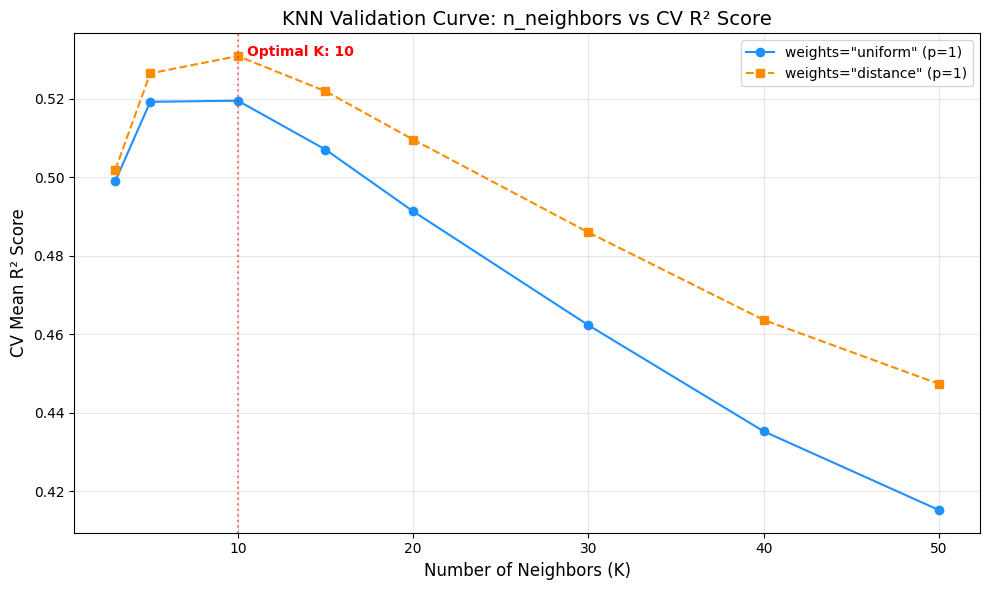

💡 [해석 가이드]
그래프가 꺾이는 정점(Sweet Spot)이 바로 최적의 이웃 수(K)입니다.
K가 너무 작으면 과적합(Noise 암기)을, 너무 크면 과소적합(미세 패턴 무시)을 의미합니다.


In [7]:
# KNN은 트리 계열과 달리 변수 중요도(Feature Importance)를 추출할 수 없습니다.
# 대신 가장 핵심 파라미터인 이웃의 수(K)가 변함에 따라 성능이 어떻게 변하는지(Elbow 꺾임)를 시각화합니다.

# 1. GridSearchCV 결과에서 가중치(weights)별 데이터 분리
results_df = pd.DataFrame(grid_search_knn.cv_results_)

# 최적의 거리 측정 방식(p)으로 데이터 필터링
best_p = grid_search_knn.best_params_['p']
filtered_results = results_df[results_df['param_p'] == best_p]

# uniform과 distance 데이터 추출
df_uniform = filtered_results[filtered_results['param_weights'] == 'uniform']
df_distance = filtered_results[filtered_results['param_weights'] == 'distance']

# 2. 시각화
plt.figure(figsize=(10, 6))

plt.plot(df_uniform['param_n_neighbors'], df_uniform['mean_test_score'], 
         marker='o', linestyle='-', label=f'weights="uniform" (p={best_p})', color='dodgerblue')
plt.plot(df_distance['param_n_neighbors'], df_distance['mean_test_score'], 
         marker='s', linestyle='--', label=f'weights="distance" (p={best_p})', color='darkorange')

plt.title('KNN Validation Curve: n_neighbors vs CV R² Score', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('CV Mean R² Score', fontsize=12)

# 최적의 K 지점 표시
best_k = grid_search_knn.best_params_['n_neighbors']
best_score = grid_search_knn.best_score_
plt.axvline(x=best_k, color='red', linestyle=':', alpha=0.5)
plt.text(best_k + 0.5, best_score, f'Optimal K: {best_k}', color='red', fontweight='bold')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 [해석 가이드]")
print("그래프가 꺾이는 정점(Sweet Spot)이 바로 최적의 이웃 수(K)입니다.")
print("K가 너무 작으면 과적합(Noise 암기)을, 너무 크면 과소적합(미세 패턴 무시)을 의미합니다.")

### [Cell 6] 예측값과 실제값 산점도 (Scatter Plot) 시각화

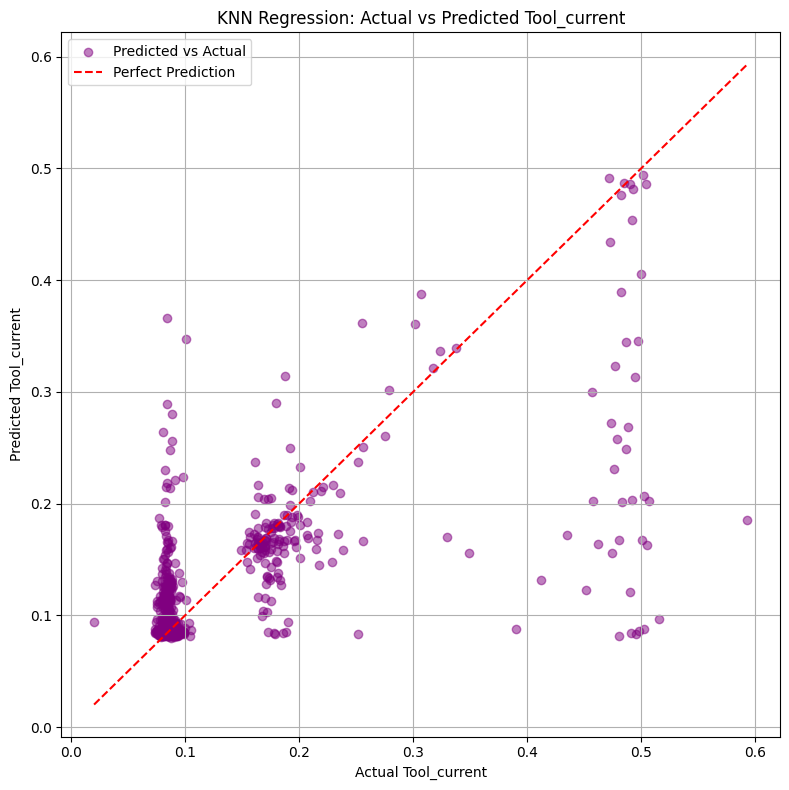

In [8]:
plt.figure(figsize=(8, 8))
# KNN은 보라색 계열로 표기하여 DT(파랑), RF(초록)와 시각적으로 구분합니다.
plt.scatter(y_test, y_test_pred_best_knn, alpha=0.5, color='purple', label='Predicted vs Actual')

# 완벽하게 예측했을 때의 대각선 (y=x)
min_val = min(y_test.min(), y_test_pred_best_knn.min())
max_val = max(y_test.max(), y_test_pred_best_knn.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.title('KNN Regression: Actual vs Predicted Tool_current')
plt.xlabel('Actual Tool_current')
plt.ylabel('Predicted Tool_current')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()